In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df=pd.read_excel("advertising_sales_data.xlsx")

In [4]:
df.head()

,Campaign,TV,Radio,Newspaper,Sales
0,camp1,230.1,37.8,69.2,22.1
1,camp2,44.5,39.3,45.1,10.4
2,camp3,17.2,45.9,69.3,12.0
3,camp4,151.5,41.3,58.5,16.5
4,camp5,180.8,10.8,58.4,17.9




---

Question 1. What is the average amount spent on TV advertising in the dataset?



---



In [5]:
#taking mean
print(df["TV"].mean())

147.0425




---

Question 2. What is the correlation between radio advertising expenditure and product sales?


---



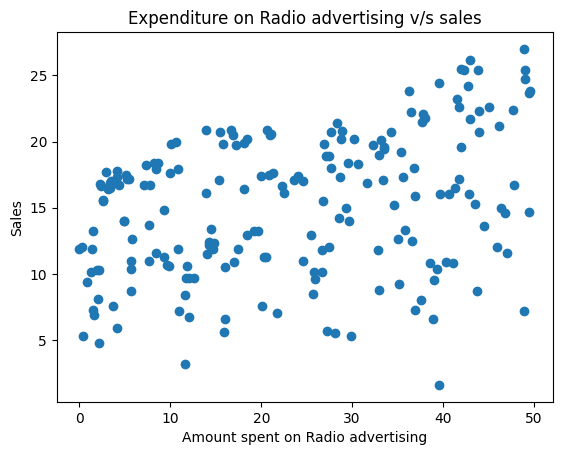

In [6]:
#scatter plot
plt.scatter(df["Radio"], df["Sales"])
plt.title("Expenditure on Radio advertising v/s sales")
plt.xlabel("Amount spent on Radio advertising")
plt.ylabel("Sales")
plt.show()

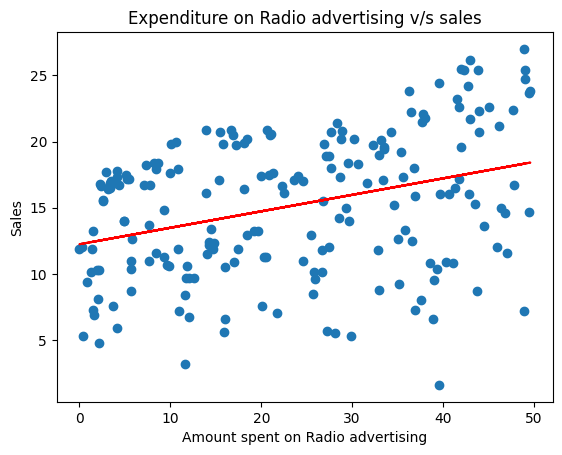

In [7]:
#using linear regression to get more information about the nature of relation
x=df[["Radio"]]
y=df['Sales']
# x.isnull().value_counts()
x=x.fillna(x.mean())
x.isnull().value_counts()
from sklearn.linear_model import LinearRegression
regressor=LinearRegression()
regressor.fit(x, y)

plt.scatter(df['Radio'], df['Sales'])
plt.plot(df['Radio'], regressor.predict(x), color="red")
plt.title("Expenditure on Radio advertising v/s sales")
plt.xlabel("Amount spent on Radio advertising")
plt.ylabel("Sales")
plt.show()

In [8]:
#correlation matrix
correlation_matrix=df[['Radio',"Sales"]].corr()
print(correlation_matrix)

          Radio     Sales
Radio  1.000000  0.349728
Sales  0.349728  1.000000


<Axes: >

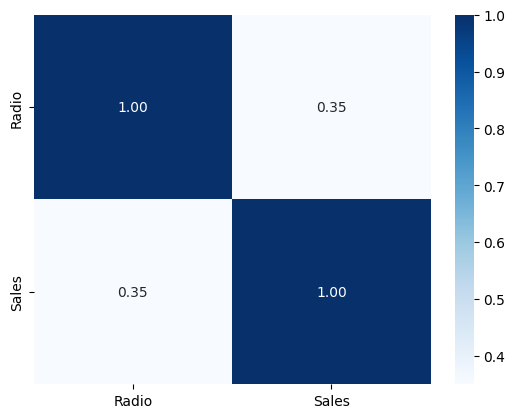

In [9]:
#visualizing the correlation matrix
import seaborn as sns

sns.heatmap(correlation_matrix, annot=True, cmap="Blues", fmt=".2f")




---

Question 3. Which advertising medium has the highest impact on sales based on the dataset?


---



In [10]:
#correlation matrix
correlation_matrix_all=df[["Sales", "Radio", "TV", "Newspaper"]].corr()
print(correlation_matrix_all)

              Sales     Radio        TV  Newspaper
Sales      1.000000  0.349728  0.901208   0.157960
Radio      0.349728  1.000000  0.054848   0.354987
TV         0.901208  0.054848  1.000000   0.056648
Newspaper  0.157960  0.354987  0.056648   1.000000


<Axes: >

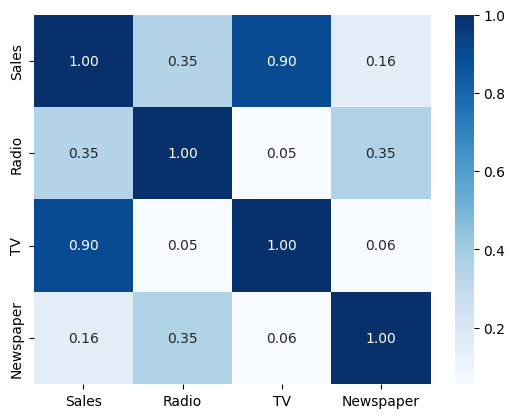

In [11]:
#visualising using heatmap
sns.heatmap(correlation_matrix_all, annot=True, cmap="Blues", fmt=".2f")



---

Question 4. Plot a linear regression line that includes all variables (TV, Radio, Newspaper) to predict Sales, and visualize the model's predictions against the actual sales values.


---



In [19]:
#creating x and y variables for linear regression model
x=df[['Radio', 'TV', 'Newspaper']]
y=df['Sales']
x=x.fillna(x.mean())

In [20]:
#splitting the data
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=1)

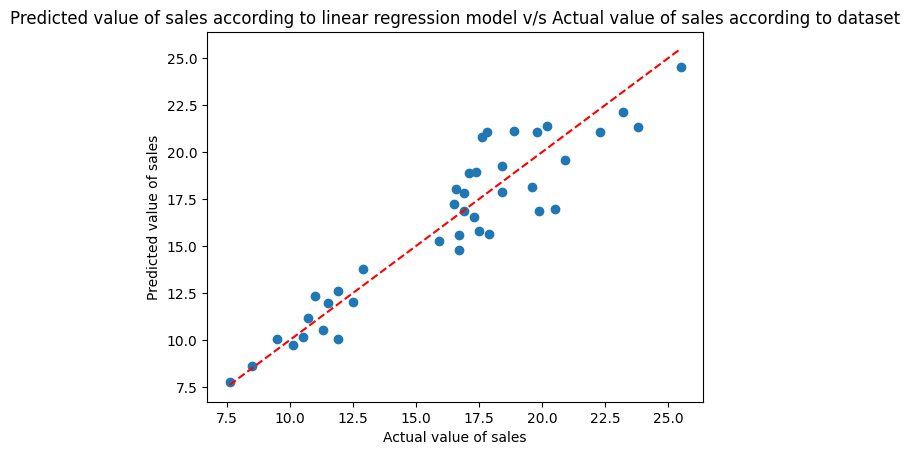

In [21]:
#training the model plotting the predicted values againt actual values
from sklearn.linear_model import LinearRegression
regressor=LinearRegression()
regressor.fit(x_train, y_train)

y_pred=regressor.predict(x_test)

plt.scatter(y_test, y_pred)
plt.title("Predicted value of sales according to linear regression model v/s Actual value of sales according to dataset")
plt.xlabel("Actual value of sales")
plt.ylabel("Predicted value of sales")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # Ideal line
plt.show()



---

Question 5. How would sales be predicted for a new set of advertising expenditures: $200 on TV, $40 on Radio, and $50 on Newspaper?


---



In [22]:
# creating the new dataset given and predicting the sale by using the model used in previous question
# x_new=[[40, 200, 50]]
x_new=pd.DataFrame({"Radio":[40], "TV":[200], "Newspaper":[50]})
predicted_sale=regressor.predict(x_new)
print("Predicted sale: ", predicted_sale)

Predicted sale:  [19.7321937]




---

Question 6. How does the performance of the linear regression model change when the dataset is normalized?


---



In [23]:
#normalizing the data using the below formula:
#normalized value = (x-xmin)/(xmax-xmin)
radio_min = df["Radio"].min()
radio_max = df["Radio"].max()

df["Radio_normalized"] = (df["Radio"] - radio_min) / (radio_max - radio_min)

tv_min=df["TV"].min()
tv_max=df["TV"].max()

df["TV_normalized"] = (df["TV"]-tv_min)/(tv_max-tv_min)

newspaper_min=df["Newspaper"].min()
newspaper_max=df["Newspaper"].max()

df["Newspaper_normalized"] = (df["Newspaper"]-newspaper_min)/(newspaper_max-newspaper_min)

sales_min=df["Sales"].min()
sales_max=df["Sales"].max()

df["Sales_nomralized"]=(df["Sales"]-sales_min)/(sales_max-sales_min)

In [24]:
#creating x and y normalized datasets for linear regression model
x_normalized=df[["Radio_normalized", "TV_normalized", "Newspaper_normalized"]]
y_normalized=df['Sales_nomralized']
x_normalized=x_normalized.fillna(x_normalized.mean())

In [25]:
#splitting the dataset
x_normalized_train, x_normalized_test, y_normalized_train, y_normalized_test=train_test_split(x_normalized, y_normalized, test_size=0.2, random_state=1)

In [26]:
#training the model
regressor.fit(x_normalized_train, y_normalized_train)

LinearRegression()

In [27]:
#predicting the value of sales
y_normalized_pred=regressor.predict(x_normalized_test)

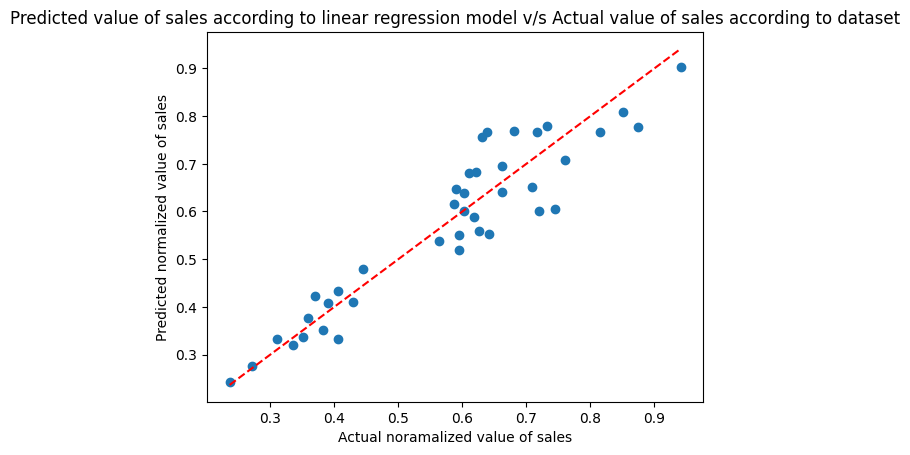

In [28]:
#plotting the predicted values and actual values
plt.scatter(y_normalized_test, y_normalized_pred)
plt.title("Predicted value of sales according to linear regression model v/s Actual value of sales according to dataset")
plt.xlabel("Actual noramalized value of sales")
plt.ylabel("Predicted normalized value of sales")
plt.plot([y_normalized_test.min(), y_normalized_test.max()], [y_normalized_test.min(), y_normalized_test.max()], 'r--')  # Ideal line
plt.show()

In [31]:
#calculating r2 and mse to identify the difference of normal data and normalized data
from sklearn.metrics import r2_score, mean_squared_error

# Original model (unnormalized)
r2_orig = r2_score(y_test, y_pred)
mse_orig = mean_squared_error(y_test, y_pred)

# Normalized model
r2_norm = r2_score(y_normalized_test, y_normalized_pred)
mse_norm = mean_squared_error(y_normalized_test, y_normalized_pred)

print("Original R²:", r2_orig)
print("Normalized R²:", r2_norm)
print("Original MSE:", mse_orig)
print("Normalized MSE:", mse_norm)


Original R²: 0.8747286106321062
Normalized R²: 0.8747286106321062
Original MSE: 2.40921857737715
Normalized MSE: 0.003734296263527109




---

Question 7. What is the impact on the sales prediction when only radio and newspaper advertising expenditures are used as predictors?


---



In [33]:
#taking radio and newspaper advertising expenditures as predictors and splitting the data
a=df[["Radio", "Newspaper"]]
b=df["Sales"]
a=a.fillna(a.mean())

a_train, a_test, b_train, b_test=train_test_split(a,b,test_size=0.2, random_state=42)

In [34]:
#trainig the model
regressor.fit(a_train, b_train)

LinearRegression()

In [35]:
#predicting the sales (dependent varaible)
b_pred=regressor.predict(a_test)

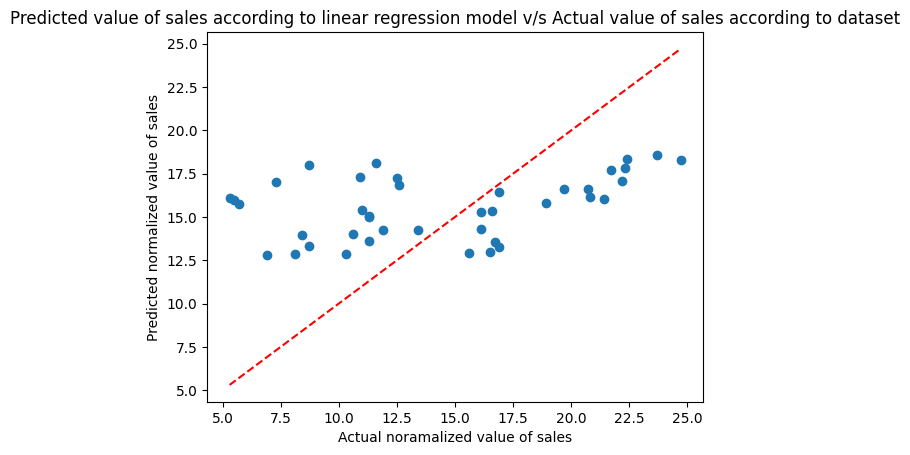

In [36]:
#plotting predicted and actual values
plt.scatter(b_test, b_pred)
plt.plot([b_test.min(), b_test.max()],[b_test.min(), b_test.max()], 'r--')
plt.title("Predicted value of sales according to linear regression model v/s Actual value of sales according to dataset")
plt.xlabel("Actual noramalized value of sales")
plt.ylabel("Predicted normalized value of sales")
plt.show()